In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import math
import csv

from scipy.stats import wasserstein_distance
from matplotlib.ticker import LogLocator, FuncFormatter

import numba
from numba import cuda, float32, int32
from numba.cuda.random import create_xoroshiro128p_states, xoroshiro128p_normal_float32

import os

from google.colab import drive

drive.mount("/content/drive")

host_seed = 42

Mounted at /content/drive


In [ ]:
widths = [3, 4, 5, 6, 8, 10] # Exclude w=2!
CaArr = [0.05, 0.1, 0.2, 0.4, 0.8]
uIDs = [i for i in range(1, 40)]

"""
In this file, I use many different directories. Some are not listed here but
can be found further into the notebook and contain "dir" in their name in order
to be easily findable. This would need to be adequately changed if one wishes to
run the relevant code snippets, but this is research-grade code and it will be
unsightly and difficult to use, as it was never my intention for this code to be
publisheable and maintainable/operable by a third party.
"""

base_dir = "/content/drive/My Drive/MSci Maths/Cleaned Data"
dic_dir = base_dir + "/PDFs"
MFPT_dir = base_dir + "/Relevant Statistics/Simulated/MFPT Data (constant dt)"
ACF_dir = base_dir + "/Relevant Statistics/Simulated/ACFs (constant dt)"

fig_dir =  "/content/drive/My Drive/MSci Maths/Figures"

emp_ACF_dir = base_dir + "/Relevant Statistics/Empirical/ACFs (full tail)"

In [ ]:
def load_nested_dic(path):
  raw = np.load(path)
  dic = {}
  for k in raw.files:
    w, Ca, field = k.split("__", 2)
    dic.setdefault((int(w), float(Ca)), {})[field] = raw[k].item()
  return dic

def load_scalar_dic(path):
  dic = {}
  with open(path, newline="") as f:
    rd = csv.DictReader(f)
    val_col = rd.fieldnames[2]
    for row in rd:
      dic[(int(row["w"]), float(row["Ca"]))] = float(row[val_col])
  return dic


# Again, the below paths would need to be adjusted.
tol_dic   = load_nested_dic(dic_dir + "/tolerances.npz")
well_dic  = load_nested_dic(dic_dir + "/wells.npz")
kappa_dic = load_scalar_dic(dic_dir + "/kappa.csv")
dt_dic    = load_scalar_dic(dic_dir + "/dt.csv")

In [ ]:
def log_exponent_formatter(val, pos):
    if val <= 0:
        return ""
    exponent = int(np.log10(val))
    return f"{exponent}"

# Loading

In [ ]:
tables_spline = {}
spline_dir = base_dir + f"/PDFs/Splines"

for w in widths:
  for Ca in CaArr:
    key = (w, Ca)
    read_path = spline_dir + f"/splines_w{w}_Ca{Ca}.npz"
    subset = np.load(read_path)

    x       = subset["x"]
    density = subset["density"]
    V       = subset["potential"]
    F       = subset["force"]
    eps     = subset["eps"]

    tables_spline[key] = {
        "x":        x,
        "density":  density,
        "V":        V,
        "F":        F,
        "eps":      eps}

# Running MFPT

## Sanity check before running long simulations

In [ ]:
def force_lookup_CPU(x, F, xmin, xmax):
  if x <= xmin:
    return F[0]
  elif x >= xmax:
    return F[-1]

  i = np.int32((x - xmin) / dx)
  i = min(max(i, 0), len(F)-2)

  x0 = xmin +i*dx
  w = (x - x0) / dx
  return (1-w)*F[i] + w*F[i+1]

In [ ]:
#raise(BufferError())
key = (6, 0.4)
subset = tables_spline[key]

xgrid = subset["x"].astype(np.float64)
Vgrid = subset["V"].astype(np.float64)
Fgrid = subset["F"].astype(np.float64)
eps = np.float64(subset["eps"])

dx = xgrid[1] - xgrid[0]
xmin = xgrid[0]
xmax = xgrid[-1]

T = 0.529 * 9000 # 0.529(s) * scaling from MFPT (Markov reduction estimate!)
dt = dt_dic[key] * 1000
N = int(T/dt) // 5
sqrt2epsdt = np.sqrt(2 * eps * dt)

x0 = 0.0
samples=np.empty(N, dtype=np.float64)

x = x0
for n in range(N):
  F = force_lookup_CPU(x, Fgrid, xmin, xmax)
  x += (-F)*dt + sqrt2epsdt*np.random.randn()

  if x < xmin:
    x = xmin + (xmin - x)
  elif x > xmax:
    x = xmax - (x - xmax)

  samples[n] = x

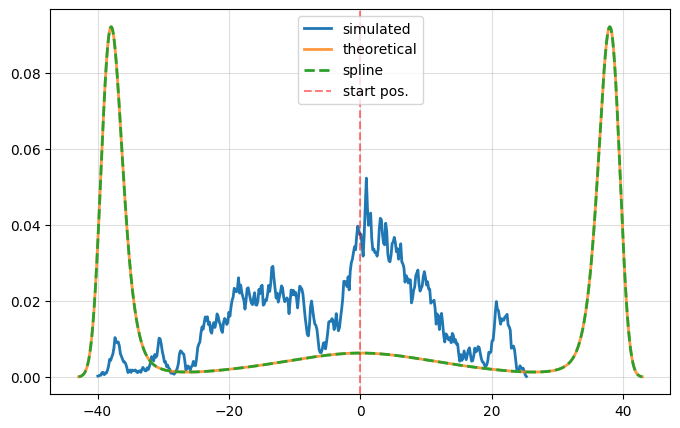

In [ ]:
hist, bins = np.histogram(samples, bins=400, density=True)
centres = 0.5 * (bins[:-1] + bins[1:])

p_theo = np.exp(-Vgrid/eps)
p_theo /= np.trapezoid(p_theo, xgrid)

p_emp = subset["density"]

plt.figure(figsize=(8,5))
plt.plot(centres, hist, label="simulated", alpha=1.0, lw=2.0)
plt.plot(xgrid, p_theo, label="theoretical", alpha=0.8, lw=2.0)
plt.plot(xgrid, p_emp, label="spline", linestyle="--", lw=2.0)
plt.axvline(x0, linestyle="--", color="r", alpha=0.5, label="start pos.")
#plt.plot(xgrid, Fgrid)
plt.legend()
plt.grid(alpha=0.4)
plt.show()

This trajectory is unstable -- stability is sensitive to ɛ.

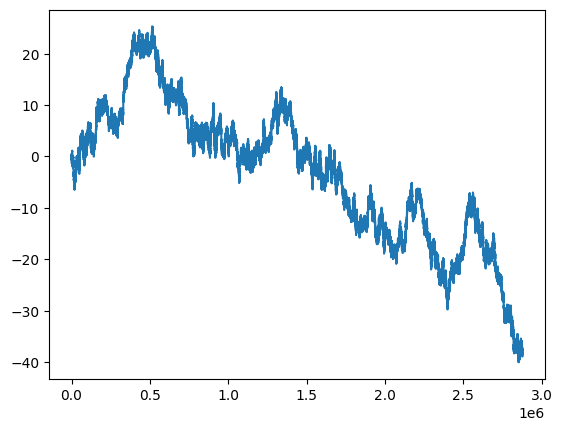

In [ ]:
plt.plot(samples)

In [ ]:
del samples

## Simulating OtO

In [ ]:
#~~~ GPU ~~~#

@cuda.jit(device=True, inline=True)
def dev_reflect_boundary(x, xb):
  """
  Device function that imposes reflective boundaries safely.
  Assumed symmetric domain [-xb, xb].
  """
  # Function is unoptimised, but got the code running with adequate performance.

  # Symmetric potential
  b2 = 2. * xb
  b4 = 4. * xb

  # Shift so we are in the interval [0, 2xb] ** floating point roundoff
  y = x + xb
  # modulo remainder
  y = math.fmod(y, b4)

  # Move to [0, b4]
  if y < 0.0:
    y = b4 + y

  # Fold into [0, b2]
  if y > b2:
    y = b4 - y

  # Shift back
  z = y - xb

  # Clamp to remove roundoff error
  if z > xb:    z = xb
  elif z < -xb: z = -xb

  return z


@cuda.jit(device=True, inline=True)
def dev_force_lookup(xq, F, dx, xmin, xmax, nF):
  """
  Device function which interpolates linearly between values not in
  the input force table (F).
  Dependent on dev_reflect_boundary().
  """
  # Reflective boundaries
  x = dev_reflect_boundary(xq, xmax)

  # Index
  u = (x - xmin) / dx
  ptr = int32(math.floor(u))

  # Clamp index pointer
  if ptr < 0:
    ptr = 0
  if ptr > nF - 2:
    ptr = nF - 2

  x_ptr = xmin + ptr * dx
  t = (x-x_ptr) / dx

  return (1.0 - t) * F[ptr] + t * F[ptr + 1]

In [ ]:
@cuda.jit
def kernel_FPT_LtoR_chunk(dev_x, dev_hit_times, dev_alive,
                          Ftab, dx, xmin, xmax, wR,
                          chunk, dt, sqrt2epsdt, rng_states):
  """
  First-Passage Time kernel via Euler-Maruyama integration.
  Runs chunk-by-chunk to avoid copying to host every iteration.

  To-do: change alive to bool array (low-priority)

  Dependent on: dev_force_lookup(), dev_reflect_boundary()
  """

  idx = cuda.grid(1)
  if idx >= dev_x.shape[0]: return
  if not dev_alive[idx]: return

  x = dev_x[idx]
  nF = Ftab.shape[0]

  for n in range(chunk):
    noise = xoroshiro128p_normal_float32(rng_states, idx)
    F = dev_force_lookup(x, Ftab, dx, xmin, xmax, nF)

    x += (-F) * dt + sqrt2epsdt * noise
    x = dev_reflect_boundary(x, xmax)

    if x >= wR:
      dev_alive[idx] = False
      dev_hit_times[idx] += (n+1) * dt
      dev_x[idx] = x
      return

  dev_hit_times[idx] += chunk * dt
  dev_x[idx] = x

In [ ]:
def launch_hits_for_MFPT_LtoR_ver1(tables_dic, tol_dic, key, dt,
                                  M=4096, Nmax=int(1e+7), chunk_size=int(1e+6),
                                  eps=np.float32(0.5), ic=np.float32(0.0),
                                  blockdim=256, rngseed=42):
  """
  GPU launcher function.
  Monte Carlo Mean First-Passage Time simulation for Left to Right basin.

  ver1: slow -- copy dev_x, dev_hit_times to host after every chunk.

  Dependent on: kernel_FPT_LtoR_chunk
  """

  griddim = int(np.ceil(M / blockdim))
  subset = tables_dic[key]

  x = np.asarray(subset["x"], dtype=np.float32)
  F_host = np.asarray(subset["F"], dtype=np.float32)

  dt = np.float32(dt)
  dx = np.float32(x[1] - x[0])
  xmin = np.float32(x[0])
  xmax = np.float32(x[-1])

  # --- Get tolerance-defined basin boundaries ---
  tol = tol_dic[key]
  wL = np.float32(tol["tol_Ll"])
  wR = np.float32(tol["tol_Rr"])
  # width==3 only has 1 barrier
  if key[0] == 3:
    wR = np.float32(tol["tol_Lr"])

  # --- Initialising ---
  if ic == "wL":
    wells = well_dic[key]
    init = wells["well_L"]

    x = np.full(M, init, dtype=np.float32)

  #elif ic == "pdf":
  #  x = sample_from_potential(subset, M=5*M, eps=eps)
  #  x = x[x <= wL]
  #  if len(x) < M:
  #    raise RuntimeError("Not enough samples in left basin.")
  #  x = x[:M].astype(np.float32)

  else:
    x = np.full(M, ic, dtype=np.float32)

  x_current = x
  hit_times = np.zeros(M, dtype=np.float32)
  alive = np.ones(M, dtype=np.bool_)

  sqrt2epsdt = np.float32(np.sqrt(2 * eps * dt))
  rng_states = create_xoroshiro128p_states(M, seed=rngseed)

  dev_F = cuda.to_device(F_host)

  # --- Launch chunk ---
  total_steps = 0

  while alive.any() and total_steps < Nmax:

    dev_x = cuda.to_device(x_current)
    dev_hit_times = cuda.to_device(hit_times)
    dev_alive = cuda.to_device(alive)

    kernel_FPT_LtoR_chunk[griddim, blockdim](
        dev_x, dev_hit_times, dev_alive, dev_F,
        dx, xmin, xmax, wR,
        chunk_size, dt, sqrt2epsdt, rng_states)

    cuda.synchronize()

    # bad copy -- see ver1 note
    x_current = dev_x.copy_to_host()
    hit_times = dev_hit_times.copy_to_host()
    alive = dev_alive.copy_to_host()

    total_steps += chunk_size

  return {"hit_times": hit_times,
          "x_final": x_current,
          "alive": alive,
          "num_hits": np.sum(~alive),
          "num_fail": np.sum(alive),
          "max_simulated_time": Nmax * dt
          }

In [ ]:
def launch_hits_for_MFPT_LtoR_ver2(tables_dic, tol_dic, key, dt,
                                  M=4096, Nmax=int(1e+7), chunk_size=int(1e+6),
                                  eps=np.float32(0.5), ic=np.float32(0.0),
                                  blockdim=256, rngseed=42):
  """
  GPU launcher function.
  Monte Carlo Mean First-Passage Time simulation for Left to Right basin.

  ver2: faster -- only copy alive to host to check how many alive
        trajectories remain. alive is an array of 1/False.
        Should change alive to be a bool array.

  Dependent on: kernel_FPT_LtoR_chunk
  """

  griddim = int(np.ceil(M / blockdim))
  subset = tables_dic[key]

  x = np.asarray(subset["x"], dtype=np.float32)
  F_host = np.asarray(subset["F"], dtype=np.float32)

  dt = np.float32(dt)
  dx = np.float32(x[1] - x[0])
  xmin = np.float32(x[0])
  xmax = np.float32(x[-1])

  # --- Get tolerance-defined basin boundaries ---
  tol = tol_dic[key]
  wL = np.float32(tol["tol_Ll"])
  wR = np.float32(tol["tol_Rr"])
  # width==3 only has 1 barrier
  if key[0] == 3:
    wR = np.float32(tol["tol_Lr"])

  # --- Initialising ---
  if ic == "wL":
    wells = well_dic[key]
    init = wells["well_L"]

    x = np.full(M, init, dtype=np.float32)

  else:
    x = np.full(M, ic, dtype=np.float32)

  hit_times = np.zeros(M, dtype=np.float32)
  alive = np.ones(M, dtype=np.bool_)

  sqrt2epsdt = np.float32(np.sqrt(2 * eps * dt))
  rng_states = create_xoroshiro128p_states(M, seed=rngseed)

  dev_x = cuda.to_device(x)
  dev_hit_times = cuda.to_device(hit_times)
  dev_alive = cuda.to_device(alive)
  dev_F = cuda.to_device(F_host)

  # --- Launch chunk ---
  total_steps = 0

  while alive.any() and total_steps < Nmax:

    kernel_FPT_LtoR_chunk[griddim, blockdim](
        dev_x, dev_hit_times, dev_alive, dev_F,
        dx, xmin, xmax, wR,
        chunk_size, dt, sqrt2epsdt, rng_states)

    cuda.synchronize()

    alive = dev_alive.copy_to_host()

    total_steps += chunk_size

  x = dev_x.copy_to_host()
  hit_times = dev_hit_times.copy_to_host()
  alive = dev_alive.copy_to_host()

  return {"hit_times": hit_times,
          "x_final": x,
          "alive": alive,
          "num_hits": np.sum(~alive),
          "num_fail": np.sum(alive),
          "max_simulated_time": Nmax * dt
          }

In [ ]:
# Number of parallel trajectories
M = 8192

# Total time steps allowed for simulation
Nmax = 300_000_000

# Run in chunks of
# Changed 10mn -> 25mn for key (6, 0.4) and onwards
Nchunk = 25_000_000

# Save path for checkpointing
OtO_dir = MFPT_dir + "/Outer to Outer"

### NOTE ON REPRODUCIBILITY:
## GPU's
# keys: (3, 0.05) -> (6, 0.05) (incl.): Used T4 GPU
# keys: (6, 0.1) onwards: Used L4 GPU
## Programme versions
# keys: (3, 0.05) -> (6, 0.4) (incl.): ver1
# keys: (6, 0.8) onwards: ver2

In [ ]:
for w in widths:
  for Ca in CaArr:
    key = (w, Ca)
    save_path = OtO_dir + f"/FPT_data_w{w}_Ca{Ca}.npz"
    print("Starting: ", key) # report progress

    if os.path.exists(save_path):
      print("Already computed: ", key)
      continue

    # LBM simulations ran for 1_600_000 steps with dt from dt_dic
    # Trajectories did not look fully "resolved" - assuming stationary
    # distributions DID exist for each system - that is.
    # Thus we run for longer... 200x more steps with 100x larger steps
    #dt = 100 * dt_dic[key]

    # We change time-stepping logic;
    dt = 1e-4
    epsilon = tables_spline[key]["eps"]

    # safe seed changing per key
    key_seed = host_seed + 1000*w + int(100*Ca) + 1

    result = launch_hits_for_MFPT_LtoR_ver2(
        tables_spline, tol_dic, key=key, dt=dt,
        M=M, Nmax=Nmax, chunk_size = Nchunk,
        eps=epsilon, ic="wL", rngseed = key_seed)

    np.savez_compressed(
        save_path,
        hit_times = result["hit_times"],
        x_final = result["x_final"],
        alive = result["alive"],
        num_success = result["num_hits"],
        num_fail = result["num_fail"],
        max_simulated_time = result["max_simulated_time"],
        dt = dt,
        epsilon = epsilon,
        M=M,
        Nmax=Nmax,
        chunk_size=Nchunk,
        seed=int(key_seed))
print("Finished!")

## Simulating OtI

In [ ]:
def launch_hits_for_MFPT_LtoC(tables_dic, tol_dic, key, dt,
                              M=4096, Nmax=int(1e+7), chunk_size=int(1e+6),
                              eps=np.float32(0.5), ic=np.float32(0.0),
                              blockdim=256, rngseed=42):
  """
  GPU launcher function.
  Monte Carlo Mean First-Passage Time simulation for Left to Central basin.

  Dependent on: kernel_FPT_LtoR_chunk
  """

  griddim = int(np.ceil(M / blockdim))
  subset = tables_dic[key]

  x = np.asarray(subset["x"], dtype=np.float32)
  F_host = np.asarray(subset["F"], dtype=np.float32)

  dt = np.float32(dt)
  dx = np.float32(x[1] - x[0])
  xmin = np.float32(x[0])
  xmax = np.float32(x[-1])

  # --- Get tolerance-defined basin boundaries ---
  tol = tol_dic[key]
  wL = np.float32(tol["tol_Ll"])
  wC = np.float32(tol["tol_Lr"])

  # --- Initialising ---
  if ic == "wL":
    wells = well_dic[key]
    init = wells["well_L"]

    x = np.full(M, init, dtype=np.float32)

  else:
    x = np.full(M, ic, dtype=np.float32)

  hit_times = np.zeros(M, dtype=np.float32)
  alive = np.ones(M, dtype=np.bool_)

  sqrt2epsdt = np.float32(np.sqrt(2 * eps * dt))
  rng_states = create_xoroshiro128p_states(M, seed=rngseed)

  dev_x = cuda.to_device(x)
  dev_hit_times = cuda.to_device(hit_times)
  dev_alive = cuda.to_device(alive)
  dev_F = cuda.to_device(F_host)

  # --- Launch chunk ---
  total_steps = 0

  while alive.any() and total_steps < Nmax:

    kernel_FPT_LtoR_chunk[griddim, blockdim](
        dev_x, dev_hit_times, dev_alive, dev_F,
        dx, xmin, xmax, wC,
        chunk_size, dt, sqrt2epsdt, rng_states)

    cuda.synchronize()

    alive = dev_alive.copy_to_host()

    total_steps += chunk_size

  x = dev_x.copy_to_host()
  hit_times = dev_hit_times.copy_to_host()
  alive = dev_alive.copy_to_host()

  return {"hit_times": hit_times,
          "x_final": x,
          "alive": alive,
          "num_hits": np.sum(~alive),
          "num_fail": np.sum(alive),
          "max_simulated_time": Nmax * dt
          }

In [ ]:
# Number of parallel trajectories
M = 32_768

# Total time steps allowed for simulation
Nmax = 100_000_000

# Run in chunks of
# Changed 10mn -> 25mn for key (6, 0.4) and onwards
Nchunk = 10_000_000

# Save path for checkpointing
OtI_dir = MFPT_dir + "/Outer to Inner"

### NOTE ON REPRODUCIBILITY:
# GPU: L4

In [ ]:
for w in widths:
  for Ca in CaArr:
    key = (w, Ca)
    save_path = OtI_dir + f"/FPT_data_w{w}_Ca{Ca}.npz"
    print("Starting: ", key) # report progress

    if os.path.exists(save_path):
      print("Already computed: ", key)
      continue

    # LBM simulations ran for 1_600_000 steps with dt from dt_dic
    # Trajectories did not look fully "resolved" - assuming stationary
    # distributions DID exist for each system - that is.
    # Thus we run for longer... 200x more steps with 100x larger steps
    #dt = 100 * dt_dic[key]

    # Changing dt logic;
    dt = 1e-4
    epsilon = tables_spline[key]["eps"]

    # safe seed changing per key
    key_seed = host_seed + 1000*w + int(100*Ca) + 1

    result = launch_hits_for_MFPT_LtoC(
        tables_spline, tol_dic, key=key, dt=dt,
        M=M, Nmax=Nmax, chunk_size = Nchunk,
        eps=epsilon, ic="wL", rngseed = int(key_seed))

    np.savez_compressed(
        save_path,
        hit_times = result["hit_times"],
        x_final = result["x_final"],
        alive = result["alive"],
        num_success = result["num_hits"],
        num_fail = result["num_fail"],
        max_simulated_time = result["max_simulated_time"],
        dt = dt,
        epsilon = epsilon,
        M=M,
        Nmax=Nmax,
        chunk_size=Nchunk,
        seed=int(key_seed))
print("Finished!")

# Simulating ACF

In [ ]:
def acovs_WK_unbiased(X): # host function
"""
Estimate unbiased autocovariance of full set of trajectories.

Dependant on: traj_acov_WK_unbiased
"""
  acovs = np.empty((np.shape(X)))
  for i in range(np.shape(X)[0]):
    acovs[i] = traj_acov_WK_unbiased(X[i])
  return acovs

def traj_acov_WK_unbiased(traj): # host function
"""
Estimate unbiased autocovariance over a single trajectory.
"""
  x = traj - np.mean(traj)
  n = len(x)
  npad = 1 << (2*n-1).bit_length() # zero-padding for fft
  Fx = np.fft.rfft(x, n=npad)
  ps = Fx * np.conjugate(Fx) # power spectrum - see Weiner Khinchin
  acov = np.fft.irfft(ps, n=npad)
  acov = acov[:n]
  count = np.arange(n, 0, -1) # counts for unbiased weighting; n, n-1, ..., 1
  return acov/count

In [ ]:
def sample_from_potential(subset, M=200, eps=1., rng=1):
  x = np.asarray(subset["x"], dtype=np.float64)
  dx = np.float64(x[1] - x[0])

  try:
    m = np.asarray(subset["density"], dtype=np.float64)
  except KeyError:
    print("Inferred from potential")
    V = np.asarray(subset["V"], dtype=np.float64)

    # non-normalised density; weight
    logw = -V / eps
    logw -= logw.max()
    w = np.exp(logw)
    m = w * dx # probability mass


  cdf = np.cumsum(m)
  total = cdf[-1]
  if not np.isfinite(total) or total <= 0:
    raise ValueError("Bad CDF; check V or epsilon.")
  cdf /= total

  # set rng
  rng = np.random.default_rng(rng)

  # uniformly choose bin
  u = rng.random(M)
  idx = np.searchsorted(cdf, u, side="right") #-> ndarray.shape = (M, )

  # handle idx==len(x) due to u==1.0
  n = len(x)
  idx[idx == n] = n-1 #this vs redraw entire selection of u so no bias

  # randomise x0 within bin
  jitter = (rng.random(M) - 0.5) * dx
  x0 = x[idx] + jitter #-> ndarray, reoreded as per idx

  xmin = x[0] - 0.5 * dx
  xmax = x[-1] + 0.5 * dx
  x0 = np.clip(x0, xmin, xmax)

  return x0.astype(np.float32)

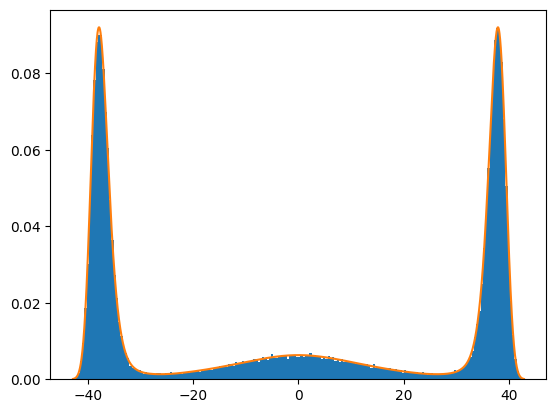

In [ ]:
subset = tables_spline[(6, 0.4)]
samples = sample_from_potential(subset, M=100000, eps=eps)

plt.hist(samples, bins=200, density=True)

V = subset["V"]
x = subset["x"]
eps = subset["eps"]


# compare against theoretical
rho = np.exp(-V/eps)
rho /= np.trapezoid(rho, x)

plt.plot(x, rho)
plt.show()

del samples, subset, V, x, eps, rho

In [ ]:
@cuda.jit
def kernel_update_traj(dev_X, Ftab, dx, xmin, xmax,
                       N, M, dt, sqrt2epsdt, rng_states):
  """
  Simple Euler-Maruyama integration step.
  Highly parallel

  Dependent on: dev_force_lookup(), dev_reflect_boundary()
  """

  glob_idx = cuda.grid(1)
  if glob_idx >= M: return

  x = dev_X[glob_idx, 0]
  nF = Ftab.shape[0]

  for i in range(N-1):
    noise = xoroshiro128p_normal_float32(rng_states, glob_idx)
    F = dev_force_lookup(x, Ftab, dx, xmin, xmax, nF)

    x += (-F) * dt + sqrt2epsdt * noise
    x = dev_reflect_boundary(x, xmax)

    dev_X[glob_idx, i+1] = x



def launch_EMOL_solver(tables_dic, key, # as (w, Ca)
                       N=25_000, M=200, dt=np.float32(2e-3),
                       eps=np.float32(0.5), ic=np.float32(0.0),
                       blockdim=256, rngseed=1):
  """
  GPU Launcher for full Euler-Maruyama integration.
  Highly parallel.

  Dependent on: kernel_update_traj, sample_from_potential (if ic=="pdf")
  """

  griddim = int(np.ceil(M/blockdim))
  subset = tables_dic[key]

  F_host = np.asarray(subset["F"], dtype=np.float32)
  x_host = np.asarray(subset["x"], dtype=np.float32)

  dx = np.float32(x_host[1] - x_host[0])
  xmin = np.float32(x_host[0])
  xmax = np.float32(x_host[-1])

  host_out = np.empty((M,N), dtype=np.float32)

  if ic=="pdf":
    host_out[:, 0] = sample_from_potential(subset, M=M, eps=eps)
  else:
    host_out[:,0] = ic

  dev_F = cuda.to_device(F_host)
  dev_out = cuda.to_device(host_out)

  rng_states = create_xoroshiro128p_states(M, seed=rngseed)
  sqrt2epsdt = np.float32(np.sqrt(2*eps*dt))

  # launch kernel
  kernel_update_traj[griddim, blockdim](dev_out, dev_F, dx, xmin, xmax,
                                        N, M, dt, sqrt2epsdt, rng_states)

  cuda.synchronize()
  return dev_out.copy_to_host()

In [ ]:
try: del X
except: pass

# For consistency with original data do not change N.
N_LBM = 64_000
M_max = 32_768

mult = 4 # for optimising GPU usage/length of trajectories

N = mult * N_LBM
M = M_max // mult

key = (8, 0.1)

epsilon = tables_spline[key]["eps"]
kappa = kappa_dic[key]
#dt = 100 * dt_dic[key]
dt = 1e-4

In [ ]:
X = launch_EMOL_solver(tables_spline, key, N, M, dt,
                       epsilon, "pdf", rngseed=host_seed)

ACFs = acovs_WK_unbiased(X)

ACFs = ACFs / ACFs[:, [0]]

ACF_mu = ACFs.mean(axis=0)
ACF_sd = ACFs.std(axis=0)

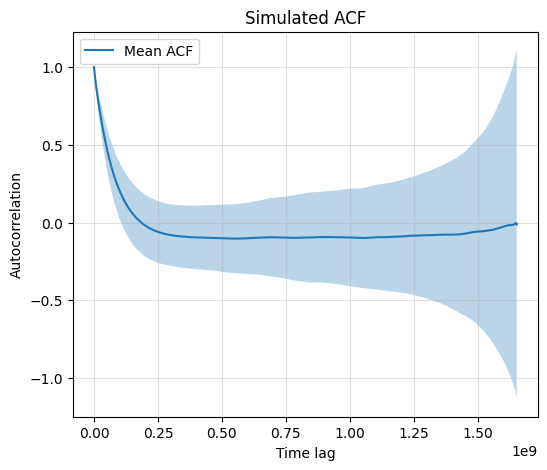

In [ ]:
lags = kappa * np.arange(len(ACF_mu))

plt.figure(figsize=(6,5))
plt.plot(lags, ACF_mu, label="Mean ACF")
plt.fill_between(lags,
                 ACF_mu - ACF_sd,
                 ACF_mu + ACF_sd,
                 alpha=0.3)
plt.xlabel("Time lag")
plt.ylabel("Autocorrelation")
plt.title("Simulated ACF")
plt.grid(alpha=0.4)

#plt.xlim(0, 64001)

plt.legend()
plt.show()

In [ ]:
del X
ACF_mu_2 = ACF_mu.copy()
ACF_sd_2 = ACF_sd.copy()

ACF_mu_2 = ACF_mu_2[:N_LBM]
ACF_sd_2 = ACF_sd_2[:N_LBM]

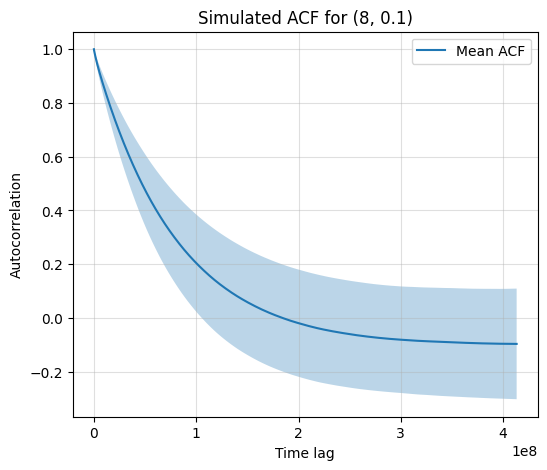

In [ ]:
lags_2 = kappa * np.arange(len(ACF_mu_2))

plt.figure(figsize=(6,5))
plt.plot(lags_2, ACF_mu_2, label="Mean ACF")
plt.fill_between(lags_2,
                 ACF_mu_2 - ACF_sd_2,
                 ACF_mu_2 + ACF_sd_2,
                 alpha=0.3)
plt.xlabel("Time lag")
plt.ylabel("Autocorrelation")
plt.title(f"Simulated ACF for {key}")
plt.grid(alpha=0.4)


plt.legend()
plt.show()

In [ ]:
for w in widths:
  for Ca in CaArr:
    key = (w, Ca)
    save_path = OtI_dir + f"/FPT_data_w{w}_Ca{Ca}.npz"

    if os.path.exists(save_path):
      print("Already computed: ", key)
      continue

    print("Starting: ", key) # report progress

    # LBM simulations ran for 1_600_000 steps with dt from dt_dic
    # Trajectories did not look fully "resolved" - assuming stationary
    # distributions DID exist for each system - that is.
    # Thus we run for longer... 200x more steps with 100x larger steps
    #dt = 100 * dt_dic[key]

    # Changing dt logic;
    dt = 1e-4
    epsilon = tables_spline[key]["eps"]

    # safe seed changing per key
    key_seed = host_seed + 1000*w + int(100*Ca) + 1

    result = launch_hits_for_MFPT_LtoC(
        tables_spline, tol_dic, key=key, dt=dt,
        M=M, Nmax=Nmax, chunk_size = Nchunk,
        eps=epsilon, ic="wL", rngseed = int(key_seed))

    np.savez_compressed(
        save_path,
        hit_times = result["hit_times"],
        x_final = result["x_final"],
        alive = result["alive"],
        num_success = result["num_hits"],
        num_fail = result["num_fail"],
        max_simulated_time = result["max_simulated_time"],
        dt = dt,
        epsilon = epsilon,
        M=M,
        Nmax=Nmax,
        chunk_size=Nchunk,
        seed=int(key_seed))
print("Finished!")

In [ ]:
for w in widths:
  for Ca in CaArr:
    save_path = ACF_dir + f"/ACF_data_w{w}_Ca{Ca}.npz"
    key = (w, Ca)

    if os.path.exists(save_path):
      print("Already computed: ", (w, Ca))
      continue

    print("Starting: ", key)

    key_seed = host_seed + 1000*w + int(100*Ca)
    #dt = 100 * dt_dic[key]
    dt = 1e-4
    epsilon = tables_spline[key]["eps"]

    X = launch_EMOL_solver(tables_spline, key, N, M, dt,
                       epsilon, "pdf", rngseed=key_seed)

    ACFs = acovs_WK_unbiased(X)
    del X

    ACFs = ACFs / ACFs[:, [0]]

    ACF_mu = ACFs.mean(axis=0)
    ACF_sd = ACFs.std(axis=0)

    np.savez_compressed(
        save_path,
        acf = ACF_mu,
        acf_sd = ACF_sd)

print("Finished!")

# General diffusion case

In [ ]:
#~~~ GPU ~~~#

@cuda.jit(device=True, inline=True)
def dev_reflect_boundary(x, xb):
  # Symmetric potential
  b2 = 2. * xb
  b4 = 4. * xb

  # Shift so we are in the interval [0, 2xb] ** floating point roundoff
  y = x + xb
  # modulo remainder
  y = math.fmod(y, b4)

  # Move to [0, b4]
  if y < 0.0:
    y = b4 + y

  # Fold into [0, b2]
  if y > b2:
    y = b4 - y

  # Shift back
  z = y - xb

  # Clamp to remove roundoff error
  if z > xb:    z = xb
  elif z < -xb: z = -xb

  return z


@cuda.jit(device=True, inline=True)
def dev_lookup(xq, tab, dx, xmin, xmax, n):
  x = dev_reflect_boundary(xq, xmax)

  u = (x - xmin) / dx
  ptr = int32(math.floor(u))

  if ptr < 0:
    ptr = 0
  if ptr > n - 2:
    ptr = n - 2

  x_ptr = xmin + ptr * dx
  t = (x - x_ptr) / dx

  return (1.0 - t) * tab[ptr] + t * tab[ptr + 1]


def sample_from_potential(subset, M=200, eps=1., rng=1):
  x = np.asarray(subset["x"], dtype=np.float64)
  dx = np.float64(x[1] - x[0])

  try:
    m = np.asarray(subset["density"], dtype=np.float64)
  except KeyError:
    print("Inferred from potential")
    V = np.asarray(subset["V"], dtype=np.float64)

    # non-normalised density; weight
    logw = -V / eps
    logw -= logw.max()
    w = np.exp(logw)
    m = w * dx # probability mass


  cdf = np.cumsum(m)
  total = cdf[-1]
  if not np.isfinite(total) or total <= 0:
    raise ValueError("Bad CDF; check V or epsilon.")
  cdf /= total

  # set rng
  rng = np.random.default_rng(rng)

  # uniformly choose bin
  u = rng.random(M)
  idx = np.searchsorted(cdf, u, side="right") #-> ndarray.shape = (M, )

  # handle idx==len(x) due to u==1.0
  n = len(x)
  idx[idx == n] = n-1 #this vs redraw entire selection of u so no bias

  # randomise x0 within bin
  jitter = (rng.random(M) - 0.5) * dx
  x0 = x[idx] + jitter #-> ndarray, reoreded as per idx

  xmin = x[0] - 0.5 * dx
  xmax = x[-1] + 0.5 * dx
  x0 = np.clip(x0, xmin, xmax)

  return x0.astype(np.float32)

def acovs_WK_unbiased(X): # host function
  acovs = np.empty((np.shape(X)))
  for i in range(np.shape(X)[0]):
    acovs[i] = traj_acov_WK_unbiased(X[i])
  return acovs

def traj_acov_WK_unbiased(traj): # host function
  x = traj - np.mean(traj)
  n = len(x)
  npad = 1 << (2*n-1).bit_length() # zero-padding for fft
  Fx = np.fft.rfft(x, n=npad)
  ps = Fx * np.conjugate(Fx) # power spectrum - see Weiner Khinchin
  acov = np.fft.irfft(ps, n=npad)
  acov = acov[:n]
  count = np.arange(n, 0, -1) # counts for unbiased weighting; n, n-1, ..., 1
  return acov/count

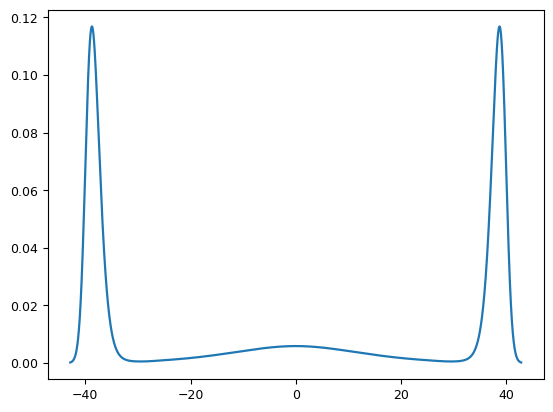

In [ ]:
plt.plot(tables_spline[(6, 0.1)]["x"], tables_spline[(6, 0.1)]["density"])

## Full

In [ ]:
@cuda.jit
def kernel_update_traj_general(dev_X, Ftab, btab, dbtab,
                               dx, xmin, xmax,
                               N, M, dt, eps, rng_states):
  """
  Euler-Maruyama integration step for general diffusion case.

  Dependent on: dev_lookup, dev_reflect_boundary
  """

  glob_idx = cuda.grid(1)
  if glob_idx >= M: return

  x = dev_X[glob_idx, 0]
  nF = Ftab.shape[0]

  for i in range(N - 1):
    noise = xoroshiro128p_normal_float32(rng_states, glob_idx)

    F = dev_lookup(x, Ftab, dx, xmin, xmax, nF)
    b = dev_lookup(x, btab, dx, xmin, xmax, nF)
    dbdx = dev_lookup(x, dbtab, dx, xmin, xmax, nF)

    # enforce positivity for safety
    if b < 0.0:
      b = 0.0

    drift = (-F * b + eps * dbdx)
    noise_amp = math.sqrt(2.0 * eps * b * dt)

    x += drift * dt + noise_amp * noise
    x = dev_reflect_boundary(x, xmax)

    dev_X[glob_idx, i + 1] = x

def launch_EMOL_solver_general(tables_dic, key,
                               b_func,
                               N=25000, M=200,
                               dt=np.float32(2e-3),
                               eps=None,
                               ic=np.float32(0.0),
                               blockdim=256,
                               rngseed=1):
  """
  GPU Launcher for full Euler-Maruyama integration.

  general: Generalised Diffusion Case;
           dX(t) = a(x)dt + b(x)dB(t)
           a(x) = -F(x)b(x) + eps * db(x)/dx
           F(x) is the potential gradient dV(x)/dx

  Dependent on: kernel_update_traj_general,
                sample_from_potential (if ic=="pdf")
  """

  griddim = int(np.ceil(M / blockdim))
  subset = tables_dic[key]

  x_host = np.asarray(subset["x"], dtype=np.float32)
  F_host = np.asarray(subset["F"], dtype=np.float32)

  dt = np.float32(dt)

  if eps is None:
    eps = np.float32(subset["eps"])
  else:
    eps = np.float32(eps)

  b_host = np.asarray(b_func(x_host), dtype=np.float32)
  db_host = np.gradient(b_host, x_host).astype(np.float32)

  if np.any(b_host < 0):
    raise ValueError("b_func must be non-negative on domain.")

  dx = np.float32(x_host[1] - x_host[0])
  xmin = np.float32(x_host[0])
  xmax = np.float32(x_host[-1])

  host_out = np.empty((M, N), dtype=np.float32)

  if ic == "pdf":
    host_out[:, 0] = sample_from_potential(subset, M=M, eps=eps)
  else:
    host_out[:, 0] = ic.astype(float32)

  dev_F = cuda.to_device(F_host)
  dev_b = cuda.to_device(b_host)
  dev_db = cuda.to_device(db_host)
  dev_out = cuda.to_device(host_out)

  rng_states = create_xoroshiro128p_states(M, seed=rngseed)

  kernel_update_traj_general[griddim, blockdim](
      dev_out,
      dev_F,
      dev_b,
      dev_db,
      dx, xmin, xmax,
      N, M,
      dt, eps,
      rng_states
  )

  cuda.synchronize()
  return dev_out.copy_to_host()

In [ ]:
# For consistency with original data do not change N.
N_LBM = 64_000
M_max = 32_768

mult = 4 # for optimising GPU usage/length of trajectories

N = mult * N_LBM
M = M_max // mult

key = (8, 0.1)
N = 25_600
M = 128

epsilon = tables_spline[key]["eps"]
kappa = kappa_dic[key]
dt = 100 * dt_dic[key]

In [ ]:
X = launch_EMOL_solver_general(tables_spline, key,
                               lambda x: 1 + 0.5*x**2,
                               N, M,
                               dt,
                               epsilon,
                               "pdf",
                               rngseed=host_seed)

#ACFs = acovs_WK_unbiased(X)

#ACFs = ACFs / ACFs[:, [0]]

#ACF_mu = ACFs.mean(axis=0)
#ACF_sd = ACFs.std(axis=0)

/usr/local/lib/python3.12/dist-packages/numba_cuda/numba/cuda/dispatcher.py:696: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


/tmp/ipykernel_963/3147397140.py:6: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  rho /= np.trapz(rho, x_grid)


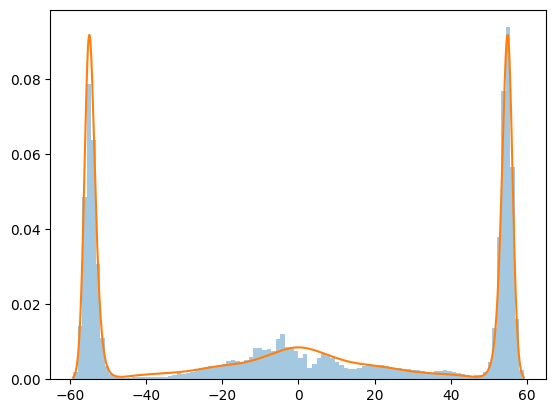

In [ ]:
x_samples = X[-15000:, -15000:].ravel()  # use late part
plt.hist(x_samples, bins=100, density=True, alpha=0.4)

x_grid = tables_spline[key]["x"]
rho = np.exp(-tables_spline[key]["V"] / epsilon)
rho /= np.trapz(rho, x_grid)

plt.plot(x_grid, rho)
plt.show()

## Stability

In [ ]:
@cuda.jit
def kernel_update_traj_cloud(dev_X, Ftab, btab, dbtab,
                             dx, xmin, xmax,
                             N, M, dt, eps, rng_states):
  """
  Euler-Maruyama integration step for general diffusion case.
  Highly parallel.

  Dependent on: dev_lookup, dev_reflect_boundary
  """

  glob_idx = cuda.grid(1)
  if glob_idx >= M: return

  x = dev_X[glob_idx]
  nF = Ftab.shape[0]

  for i in range(N - 1):
    noise = xoroshiro128p_normal_float32(rng_states, glob_idx)

    F = dev_lookup(x, Ftab, dx, xmin, xmax, nF)
    b = dev_lookup(x, btab, dx, xmin, xmax, nF)
    dbdx = dev_lookup(x, dbtab, dx, xmin, xmax, nF)

    # enforce positivity for safety
    if b < 0.0:
      b = 0.0

    drift = (-F * b + eps * dbdx)
    noise_amp = math.sqrt(2.0 * eps * b * dt)

    x += drift * dt + noise_amp * noise
    x = dev_reflect_boundary(x, xmax)

    dev_X[glob_idx] = x

def launch_EMOL_solver_cloud(tables_dic, key,
                             b_func,
                             N=25000, M=200,
                             dt=np.float32(2e-3),
                             eps=None,
                             ic=np.float32(0.0),
                             blockdim=256,
                             rngseed=1):
  """
  GPU Launcher for full Euler-Maruyama integration.
  Highly parallel.
  b
  general: Generalised Diffusion Case;
           dX(t) = a(x)dt + b(x)dB(t)
           a(x) = -F(x)b(x) + eps * db(x)/dx
           F(x) is the potential gradient dV(x)/dx

  Dependent on: kernel_update_traj_general,
                sample_from_potential (if ic=="pdf")
  """

  griddim = int(np.ceil(M / blockdim))
  subset = tables_dic[key]

  x_host = np.asarray(subset["x"], dtype=np.float32)
  F_host = np.asarray(subset["F"], dtype=np.float32)

  dt = np.float32(dt)

  if eps is None:
    eps = np.float32(subset["eps"])
  else:
    eps = np.float32(eps)

  b_val = b_func(x_host)

  # If scalar, broadcast
  if np.isscalar(b_val):
    b_host = np.full_like(x_host, b_val, dtype=np.float32)
  else:
    b_host = np.asarray(b_val, dtype=np.float32)

  if b_host.shape != x_host.shape:
    raise ValueError("b_func must return scalar or array same shape as x.")

  db_host = np.gradient(b_host, x_host, edge_order=2).astype(np.float32)

  if np.any(b_host < 0):
    raise ValueError("b_func must be non-negative on domain.")

  dx = np.float32(x_host[1] - x_host[0])
  xmin = np.float32(x_host[0])
  xmax = np.float32(x_host[-1])

  host_out = np.empty((M,), dtype=np.float32)

  if ic == "pdf":
    host_out[:] = sample_from_potential(subset, M=M, eps=eps)
  else:
    host_out[:] = np.float32(ic)

  dev_F = cuda.to_device(F_host)
  dev_b = cuda.to_device(b_host)
  dev_db = cuda.to_device(db_host)
  dev_out = cuda.to_device(host_out)

  rng_states = create_xoroshiro128p_states(M, seed=rngseed)

  kernel_update_traj_cloud[griddim, blockdim](
      dev_out,
      dev_F,
      dev_b,
      dev_db,
      dx, xmin, xmax,
      N, M,
      dt, eps,
      rng_states
  )

  cuda.synchronize()
  return dev_out.copy_to_host()

In [ ]:
X_cloud = launch_EMOL_solver_cloud(tables_spline,
                                   (6, 0.1),
                                   b_func = lambda x: 1,
                                   N=25000,
                                   M=64000,
                                   dt=2,
                                   eps=None,
                                   ic="pdf")

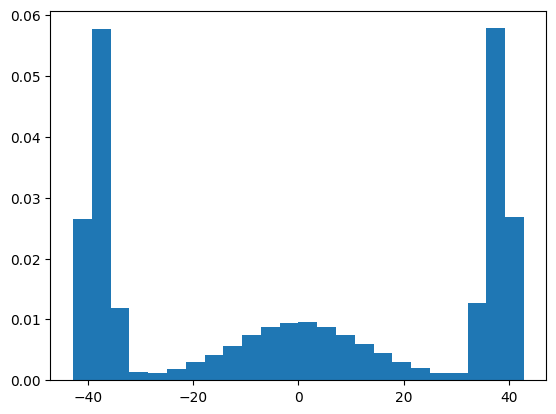

In [ ]:
plt.hist(X_cloud, density=True, bins="fd")
plt.show()

In [ ]:
def density_distance(X_samples,
                     x_grid,
                     density,
                     bins=200):

    # ----------------------------
    # Simulated density
    # ----------------------------
    hist, edges = np.histogram(
        X_samples,
        bins=bins,
        density=True)
    centers = 0.5 * (edges[:-1] + edges[1:])

    # Interpolate theory to histogram centers
    rho_interp = np.interp(centers, x_grid, density)

    # L2 distance
    dx = centers[1] - centers[0]
    L2 = np.sqrt(np.sum((hist - rho_interp) ** 2) * dx)

    # Wasserstein distance
    F_sim = np.cumsum(hist) * dx
    F_sim /= F_sim[-1]

    F_theory = np.cumsum(rho_interp) * dx
    F_theory /= F_theory[-1]

    W = np.sum(np.abs(F_sim - F_theory)) * dx


    return L2, W

In [ ]:
def evaluate_dt_across_regimes(tables_dic, keys,
                               b_func,
                               dts,
                               Tmax, M,
                               rngseed=1):

  worst_L2 = []
  worst_W = []

  for dt in dts:
    print(f"Testing dt = {dt}")

    N = int(np.ceil(Tmax/dt))

    L2_vals = []
    W_vals = []

    for i, key in enumerate(keys):

      subset = tables_dic[key]
      key_seed = rngseed + i

      X_cloud = launch_EMOL_solver_cloud(
                tables_dic,
                key=key,
                b_func=b_func,
                N=N,
                M=M,
                dt=dt,
                eps=None,
                ic="pdf",
                rngseed=key_seed)

      L2, W = density_distance(
              X_cloud,
              subset["x"],
              subset["density"])

      L2_vals.append(L2)
      W_vals.append(W)

    worst_L2.append(max(L2_vals))
    worst_W.append(max(W_vals))

    print("Worst L2:", worst_L2[-1])
    print("Worst W:", worst_W[-1])
    print("--------")

  return np.array(worst_L2), np.array(worst_W)

In [ ]:
def compute_barrier_height(subset):
  x = subset["x"]
  V = subset["V"]
  eps = subset["eps"]

  # crude: find local minima and maxima
  Vpp = np.gradient(np.gradient(V, x), x)

  minima = np.where((Vpp > 0))[0]
  maxima = np.where((Vpp < 0))[0]

  # assume symmetric double well:
  # pick deepest well and nearest saddle

  well_idx = minima[np.argmin(V[minima])]
  saddle_idx = maxima[np.argmin(np.abs(x[maxima]))]

  DeltaV = V[saddle_idx] - V[well_idx]

  return DeltaV / eps

# ============================

worst_key = None
worst_val = -np.inf

for key in tables_spline:
  subset = tables_spline[key]

  val = compute_barrier_height(subset)

  if val > worst_val:
    worst_val = val
    worst_key = key

print(worst_key, worst_val)

(6, 0.1) 5.098494551338449


In [ ]:
dts = [2, 2**(-1), 2**(-2), 2**(-3), 2**(-4), 2**(-5),
       2**(-6), 2**(-7), 2**(-8), 2**(-9), 2**(-10),
       2**(-11), 2**(-12), 2**(-13)]

worst_L2, worst_W = evaluate_dt_across_regimes(
    tables_spline,
    keys = [(6, 0.1)],  # longest transition regime
    b_func=lambda x: 1,
    dts = dts,
    Tmax = 740.0,         # enough time for ~5 OtI transitons
    M = 131_072,
    rngseed=host_seed)

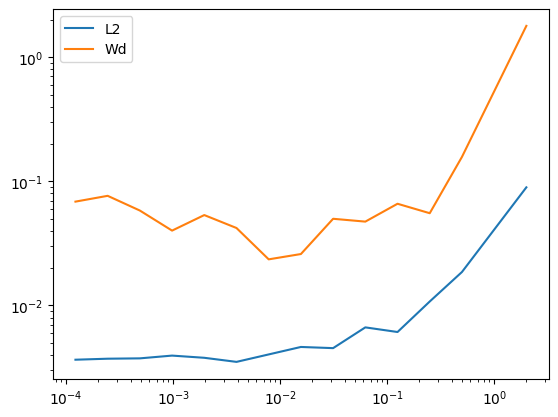

In [ ]:
plt.loglog(dts, worst_L2, label="L2")
plt.loglog(dts, worst_W, label="Wd")
plt.legend()
plt.show()

In [ ]:
X_stable = launch_EMOL_solver_cloud(
          tables_spline,
          key=(6, 0.1),
          b_func=lambda x:1,
          N=int(np.ceil(740.0/2**(-10))),
          M=131_072,
          dt=2**(-10),
          eps=None,
          ic="pdf",
          rngseed=host_seed)

X_unstable = launch_EMOL_solver_cloud(
          tables_spline,
          key=(6, 0.1),
          b_func=lambda x:1,
          N=int(np.ceil(740.0/2)),
          M=131_072,
          dt=2.0,
          eps=None,
          ic="pdf",
          rngseed=host_seed)

## Saving stability plot

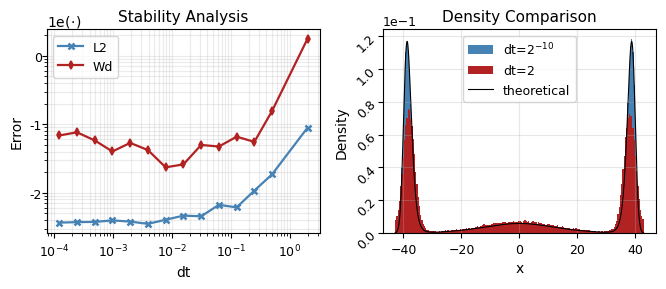

In [ ]:
subset = tables_spline[(6, 0.1)]

x_grid = subset["x"]
dens = subset["density"]

fig, axes = plt.subplots(1, 2, figsize=(6.76, 3.0), constrained_layout=False)
# ===============================
# LEFT: Stability curve
# ===============================
ax0 = axes[0]

ax0.loglog(dts, worst_L2, marker='x', mew=1.8, ms=4, label="L2", color="steelblue")
ax0.loglog(dts, worst_W, marker='d', mew=1.2, ms=4, label="Wd", color="firebrick")

ax0.set_xlabel("dt")
#ax0.text(0.5, -0.2, "dt", transform=ax0.transAxes, rotation=0, ha="center")
ax0.set_ylabel("Error")
ax0.set_title("Stability Analysis")

ax0.tick_params(axis="y", rotation=0, pad=0)
ax0.yaxis.set_major_locator(LogLocator(base=10))
ax0.yaxis.set_major_formatter(FuncFormatter(log_exponent_formatter))
ax0.text(0.00, 1.00, r"1e$(\!\cdot\!)$", transform=ax0.transAxes, ha="left", va="bottom")

ax0.grid(True, which="both", alpha=0.25)
ax0.legend()



ax1 = axes[1]
rho = np.exp(-V / eps)
rho /= np.trapezoid(rho, x_grid)

ax1.hist(X_stable, bins=200, label="dt=$2^{-10}$", density=True, color="steelblue")
ax1.hist(X_unstable, bins=200, label="dt=$2$", density=True, color="firebrick")
ax1.plot(x_grid, dens, 'k-', label="theoretical", lw=0.8)

ax1.set_xlabel("x")
ax1.set_ylabel("Density")
ax1.set_title("Density Comparison")
ax1.tick_params(axis="y", rotation=45, pad=0)
ax1.ticklabel_format(style="sci", axis="y", scilimits=(0,0))
ax1.grid(True, alpha=0.3)
ax1.legend()

plt.tight_layout(rect=[0,0,1,1])
fig_name="SDE_weak_stability"
#plt.savefig(fig_dir + "/" + fig_name + ".pdf", bbox_inches="tight")
plt.show()

# Example functions

## Define functions

In [ ]:
#~~~ GPU ~~~#

@cuda.jit(device=True, inline=True)
def dev_reflect_boundary(x, xb):
  # Symmetric potential
  b2 = 2. * xb
  b4 = 4. * xb

  # Shift so we are in the interval [0, 2xb] ** floating point roundoff
  y = x + xb
  # modulo remainder
  y = math.fmod(y, b4)

  # Move to [0, b4]
  if y < 0.0:
    y = b4 + y

  # Fold into [0, b2]
  if y > b2:
    y = b4 - y

  # Shift back
  z = y - xb

  # Clamp to remove roundoff error
  if z > xb:    z = xb
  elif z < -xb: z = -xb

  return z


@cuda.jit(device=True, inline=True)
def dev_lookup(xq, tab, dx, xmin, xmax, n):
  x = dev_reflect_boundary(xq, xmax)

  u = (x - xmin) / dx
  ptr = int32(math.floor(u))

  if ptr < 0:
    ptr = 0
  if ptr > n - 2:
    ptr = n - 2

  x_ptr = xmin + ptr * dx
  t = (x - x_ptr) / dx

  return (1.0 - t) * tab[ptr] + t * tab[ptr + 1]


def sample_from_potential(subset, M=200, eps=1., rng=1):
  x = np.asarray(subset["x"], dtype=np.float64)
  dx = np.float64(x[1] - x[0])

  try:
    m = np.asarray(subset["density"], dtype=np.float64)
  except KeyError:
    print("Inferred from potential")
    V = np.asarray(subset["V"], dtype=np.float64)

    # non-normalised density; weight
    logw = -V / eps
    logw -= logw.max()
    w = np.exp(logw)
    m = w * dx # probability mass


  cdf = np.cumsum(m)
  total = cdf[-1]
  if not np.isfinite(total) or total <= 0:
    raise ValueError("Bad CDF; check V or epsilon.")
  cdf /= total

  # set rng
  rng = np.random.default_rng(rng)

  # uniformly choose bin
  u = rng.random(M)
  idx = np.searchsorted(cdf, u, side="right") #-> ndarray.shape = (M, )

  # handle idx==len(x) due to u==1.0
  n = len(x)
  idx[idx == n] = n-1 #this vs redraw entire selection of u so no bias

  # randomise x0 within bin
  jitter = (rng.random(M) - 0.5) * dx
  x0 = x[idx] + jitter #-> ndarray, reoreded as per idx

  xmin = x[0] - 0.5 * dx
  xmax = x[-1] + 0.5 * dx
  x0 = np.clip(x0, xmin, xmax)

  return x0.astype(np.float32)

In [ ]:
def acovs_WK_unbiased(X): # host function
  acovs = np.empty((np.shape(X)))
  for i in range(np.shape(X)[0]):
    acovs[i] = traj_acov_WK_unbiased(X[i])
  return acovs

def traj_acov_WK_unbiased(traj): # host function
  x = traj - np.mean(traj)
  n = len(x)
  npad = 1 << (2*n-1).bit_length() # zero-padding for fft
  Fx = np.fft.rfft(x, n=npad)
  ps = Fx * np.conjugate(Fx) # power spectrum - see Weiner Khinchin
  acov = np.fft.irfft(ps, n=npad)
  acov = acov[:n]
  count = np.arange(n, 0, -1) # counts for unbiased weighting; n, n-1, ..., 1
  return acov/count

In [ ]:
# Only last state kept:

@cuda.jit
def kernel_update_traj_cloud(dev_X, Ftab, btab, dbtab,
                             dx, xmin, xmax,
                             N, M, dt, eps, rng_states):

  glob_idx = cuda.grid(1)
  if glob_idx >= M: return

  x = dev_X[glob_idx]
  nF = Ftab.shape[0]

  for i in range(N - 1):
    noise = xoroshiro128p_normal_float32(rng_states, glob_idx)

    F = dev_lookup(x, Ftab, dx, xmin, xmax, nF)
    b = dev_lookup(x, btab, dx, xmin, xmax, nF)
    dbdx = dev_lookup(x, dbtab, dx, xmin, xmax, nF)

    # enforce positivity for safety
    if b < 0.0:
      b = 0.0

    drift = (-F * b + eps * dbdx)
    noise_amp = math.sqrt(2.0 * eps * b * dt)

    x += drift * dt + noise_amp * noise
    x = dev_reflect_boundary(x, xmax)

    dev_X[glob_idx] = x

def launch_EMOL_solver_cloud(tables_dic, key,
                             b_func,
                             N=25000, M=200,
                             dt=np.float32(2e-3),
                             eps=None,
                             ic=np.float32(0.0),
                             blockdim=256,
                             rngseed=1):

  griddim = int(np.ceil(M / blockdim))
  subset = tables_dic[key]

  x_host = np.asarray(subset["x"], dtype=np.float32)
  F_host = np.asarray(subset["F"], dtype=np.float32)

  dt = np.float32(dt)

  if eps is None:
    eps = np.float32(subset["eps"])
  else:
    eps = np.float32(eps)

  b_val = b_func(x_host)

  # If scalar, broadcast
  if np.isscalar(b_val):
    b_host = np.full_like(x_host, b_val, dtype=np.float32)
  else:
    b_host = np.asarray(b_val, dtype=np.float32)

  if b_host.shape != x_host.shape:
    raise ValueError("b_func must return scalar or array same shape as x.")

  db_host = np.gradient(b_host, x_host, edge_order=2).astype(np.float32)

  if np.any(b_host < 0):
    raise ValueError("b_func must be non-negative on domain.")

  dx = np.float32(x_host[1] - x_host[0])
  xmin = np.float32(x_host[0])
  xmax = np.float32(x_host[-1])

  host_out = np.empty((M,), dtype=np.float32)

  if ic == "pdf":
    host_out[:] = sample_from_potential(subset, M=M, eps=eps)
  else:
    host_out[:] = np.float32(ic)

  dev_F = cuda.to_device(F_host)
  dev_b = cuda.to_device(b_host)
  dev_db = cuda.to_device(db_host)
  dev_out = cuda.to_device(host_out)

  rng_states = create_xoroshiro128p_states(M, seed=rngseed)

  kernel_update_traj_cloud[griddim, blockdim](
      dev_out,
      dev_F,
      dev_b,
      dev_db,
      dx, xmin, xmax,
      N, M,
      dt, eps,
      rng_states
  )

  cuda.synchronize()
  return dev_out.copy_to_host()

In [ ]:
# Full trajectory data

@cuda.jit
def kernel_update_traj_general(dev_X, Ftab, btab, dbtab,
                               dx, xmin, xmax,
                               N, M, dt, eps, rng_states):

  glob_idx = cuda.grid(1)
  if glob_idx >= M: return

  x = dev_X[glob_idx, 0]
  nF = Ftab.shape[0]

  for i in range(N - 1):
    noise = xoroshiro128p_normal_float32(rng_states, glob_idx)

    F = dev_lookup(x, Ftab, dx, xmin, xmax, nF)
    b = dev_lookup(x, btab, dx, xmin, xmax, nF)
    dbdx = dev_lookup(x, dbtab, dx, xmin, xmax, nF)

    # enforce positivity for safety
    if b < 0.0:
      b = 0.0

    drift = (-F * b + eps * dbdx)
    noise_amp = math.sqrt(2.0 * eps * b * dt)

    x += drift * dt + noise_amp * noise
    x = dev_reflect_boundary(x, xmax)

    dev_X[glob_idx, i + 1] = x

def launch_EMOL_solver_general(tables_dic, key,
                               b_func,
                               N=25000, M=200,
                               dt=np.float32(2e-3),
                               eps=None,
                               ic=np.float32(0.0),
                               blockdim=256,
                               rngseed=1):

  griddim = int(np.ceil(M / blockdim))
  subset = tables_dic[key]

  x_host = np.asarray(subset["x"], dtype=np.float32)
  F_host = np.asarray(subset["F"], dtype=np.float32)

  dt = np.float32(dt)

  if eps is None:
    eps = np.float32(subset["eps"])
  else:
    eps = np.float32(eps)

  b_val = b_func(x_host)

  if np.isscalar(b_val):
      b_host = np.full_like(x_host, b_val, dtype=np.float32)
  else:
      b_host = np.asarray(b_val, dtype=np.float32)

  if b_host.shape != x_host.shape:
      raise ValueError("b_func must return scalar or array matching x grid.")

  if np.any(b_host < 0):
      raise ValueError("b_func must be non-negative on domain.")

  db_host = np.gradient(b_host, x_host, edge_order=2).astype(np.float32)

  dx = np.float32(x_host[1] - x_host[0])
  xmin = np.float32(x_host[0])
  xmax = np.float32(x_host[-1])

  host_out = np.empty((M, N), dtype=np.float32)

  if ic == "pdf":
    host_out[:, 0] = sample_from_potential(subset, M=M, eps=eps)
  else:
    host_out[:, 0] = ic.astype(float32)

  dev_F = cuda.to_device(F_host)
  dev_b = cuda.to_device(b_host)
  dev_db = cuda.to_device(db_host)
  dev_out = cuda.to_device(host_out)

  rng_states = create_xoroshiro128p_states(M, seed=rngseed)

  kernel_update_traj_general[griddim, blockdim](
      dev_out,
      dev_F,
      dev_b,
      dev_db,
      dx, xmin, xmax,
      N, M,
      dt, eps,
      rng_states
  )

  cuda.synchronize()
  return dev_out.copy_to_host()

In [ ]:
def launch_hits_for_MFPT_LtoR(tables_dic, key, b_func,
                              wL, wRtol,
                              Nmax=25_000, M=200,
                              dt=1e-3, eps=None, ic="pdf",
                              blockdim=256, rngseed=1):

  subset = tables_dic[key]

  x_grid = np.asarray(subset["x"], dtype=np.float32)
  F_host = np.asarray(subset["F"], dtype=np.float32)

  dt = np.float32(dt)

  if eps is None:
      eps = np.float32(subset["eps"])
  else:
      eps = np.float32(eps)

  # --- Build b(x) and db/dx ---
  b_val = b_func(x_grid)

  if np.isscalar(b_val):
      b_host = np.full_like(x_grid, b_val, dtype=np.float32)
  else:
      b_host = np.asarray(b_val, dtype=np.float32)

  if b_host.shape != x_grid.shape:
      raise ValueError("b_func must return scalar or array matching x grid.")

  if np.any(b_host < 0):
      raise ValueError("b_func must be non-negative.")

  db_host = np.gradient(b_host, x_grid, edge_order=2).astype(np.float32)

  dx = np.float32(x_grid[1] - x_grid[0])
  xmin = np.float32(x_grid[0])
  xmax = np.float32(x_grid[-1])
  wR = np.float32(wRtol)
  wL = np.float32(wL)

  # --- Initial condition ---
  if ic == "wL":
      x0 = np.full(M, wL, dtype=np.float32)

  elif ic == "pdf":
      x0_all = sample_from_potential(subset, M=5*M, eps=eps)
      x0_left = x0_all[x0_all <= wL]

      if len(x0_left) < M:
          raise RuntimeError("Not enough samples in left well.")

      x0 = x0_left[:M].astype(np.float32)

  else:
      x0 = np.full(M, np.float32(ic), dtype=np.float32)

  # --- Allocate device memory ---
  dev_hit_steps = cuda.device_array(M, dtype=np.int32)
  dev_xhit = cuda.device_array(M, dtype=np.float32)

  dev_x0 = cuda.to_device(x0)
  dev_F = cuda.to_device(F_host)
  dev_b = cuda.to_device(b_host)
  dev_db = cuda.to_device(db_host)

  rng_states = create_xoroshiro128p_states(M, seed=rngseed)

  griddim = int(np.ceil(M / blockdim))

  kernel_hits_for_MFPT_LtoR[griddim, blockdim](
      dev_hit_steps,
      dev_xhit,
      dev_x0,
      dev_F,
      dev_b,
      dev_db,
      dx,
      xmin,
      xmax,
      wR,
      Nmax,
      M,
      dt,
      eps,
      rng_states
  )

  cuda.synchronize()

  hit_steps = dev_hit_steps.copy_to_host()
  xhit = dev_xhit.copy_to_host()

  return hit_steps, xhit

In [ ]:
@cuda.jit
def kernel_hits_for_MFPT_LtoR(dev_hit_steps, dev_xhit, dev_x0,
                              Ftab, btab, dbtab,
                              dx, xmin, xmax, wR,
                              Nmax, M,
                              dt, eps,
                              rng_states):

  idx = cuda.grid(1)
  if idx >= M: return

  x = dev_x0[idx]
  nF = Ftab.shape[0]
  hit = -1
  xhit = x

  for n in range(Nmax):
    noise = xoroshiro128p_normal_float32(rng_states, idx)

    F = dev_lookup(x, Ftab, dx, xmin, xmax, nF)
    b = dev_lookup(x, btab, dx, xmin, xmax, nF)
    dbdx = dev_lookup(x, dbtab, dx, xmin, xmax, nF)

    # enforce positivity for safety
    if b < 0.0:
      b = 0.0

    drift = (-F * b + eps * dbdx)
    noise_amp = math.sqrt(2.0 * eps * b * dt)

    x += drift * dt + noise_amp * noise
    x = dev_reflect_boundary(x, xmax)

    if x >= wR:
      hit = n
      xhit = x
      break

  dev_hit_steps[idx] = hit
  dev_xhit[idx] = xhit



def launch_hits_for_MFPT_LtoR(tables_dic, key, b_func,
                              wRtol, Nmax=25_000, M=200,
                              dt=1e-3, eps=None, ic="pdf",
                              blockdim=256, rngseed=host_seed):

  """
  Automatically locates left well
  Requires wRtol = tolerance after barrier defining hysteric right-well state
  """

  griddim = int(np.ceil(M/blockdim))
  subset = tables_dic[key]

  x_host = np.asarray(subset["x"], dtype=np.float32)
  V_host = np.asarray(subset["V"], dtype=np.float32)
  F_host = np.asarray(subset["F"], dtype=np.float32)

  dx = np.float32(x[1] - x[0])
  xmin = np.float32(x[0])
  xmax = np.float32(x[-1])

  dt = np.float32(dt)
  if eps is None:
    eps = np.float32(subset["eps"])
  else:
    eps = np.float32(eps)

  # B(x)
  b_val = b_func(x_host)

  if np.isscalar(b_val):
    b_host = np.full_like(x_host, b_val, dtype=np.float32)
  else:
    b_host = np.asarray(b_val, dtype=np.float32)
  db_host = np.gradient(b_host, x_host)

  if np.any(b_host < 0):
    raise ValueError("b_func must be non-negative.")

  # Wells
  def get_left_well(V, x):
    dV = np.gradient(V, x)
    sign_change = np.diff(np.sign(dV))
    min_idx = np.where(sign_change > 0)[0] + 1

    if len(min_idx) < 2:
      raise RuntimeError("Potential not clearly double-well.")

    left_idx = min_idx[x[min_idx] < 0][0]
    return np.float32(x[left_idx])

  wR = np.float32(wRtol)
  wL = get_left_well(V_host, x_host)

  if ic=="wL":
    x0 = np.full(M, wL, dtype=np.float32)
  elif ic=="pdf":
    x0 = sample_from_potential(subset, M=5*M, eps=eps)
    x0 = x0[x0 <= wL]
    if len(x0) < M:
      raise RuntimeError("Not enough samples in left well. Try again.")
    x0 = x0[:M].astype(np.float32)
  else:
    x0 = np.full(M, ic, dtype=np.float32)


  dev_hit_steps = cuda.device_array(M, dtype=np.int32)
  dev_xhit = cuda.device_array(M, dtype=np.float32)

  dev_x0 = cuda.to_device(x0)
  dev_F = cuda.to_device(F_host)
  dev_b = cuda.to_device(b_host)
  dev_db = cuda.to_device(db_host)

  rng_states = create_xoroshiro128p_states(M, seed=rngseed)

  kernel_hits_for_MFPT_LtoR[griddim, blockdim](
      dev_hit_steps,
      dev_xhit,
      dev_x0,
      dev_F,
      dev_b,
      dev_db,
      dx,
      xmin,
      xmax,
      wR,
      Nmax,
      M,
      dt,
      eps,
      rng_states
  )

  cuda.synchronize()

  hit_steps = dev_hit_steps.copy_to_host()
  xhit = dev_xhit.copy_to_host()

  return hit_steps, xhit

## Running simulations

In [ ]:
for w in [3]:
  x_aggr = []
  for Ca in CaArr:
    x_aggr.append(tables_spline[(3, Ca)]["x"])

  xmin = np.min(x_aggr)
  xmax = np.max(x_aggr)
  print(f"For w={w}: {xmin}, {xmax}")

For w=3: -15.496691819040606, 15.496691819040606


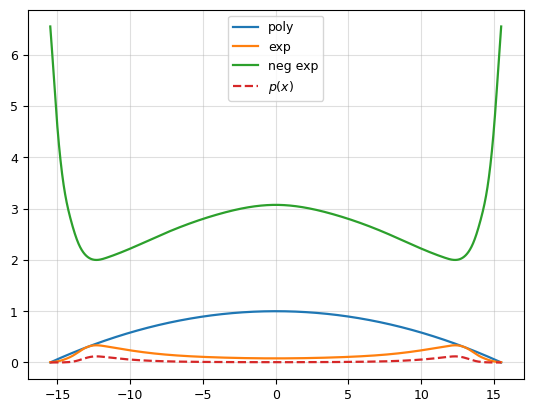

In [ ]:
# L = 15.5 for w=3
def b_func1(x, alpha=1.0, beta=1.0, L=15.5):
  return alpha * (1 - beta * (x/L)**2)

def b_func2(x, V=tables_spline[(3, 0.1)]["V"], alpha=1.0, beta=0.5):
  return alpha * np.exp(-beta * V)

def b_func3(x, V=tables_spline[(3, 0.1)]["V"], alpha=2.0, beta=-0.15):
  Vmin = V.min()
  return alpha * np.exp(-beta * (V - Vmin))

x = tables_spline[(3, 0.1)]["x"]
dens = tables_spline[(3, 0.1)]["density"]

plt.plot(x, b_func1(x), label="poly")
plt.plot(x, b_func2(x), label="exp")
plt.plot(x, b_func3(x), label="neg exp")
plt.plot(x, dens, ls="--", label="$p(x)$")
plt.legend()
plt.grid(alpha=0.4)

In [ ]:
for w in [8]:
  x_aggr = []
  for Ca in CaArr:
    x_aggr.append(tables_spline[(w, Ca)]["x"])

  xmin = np.min(x_aggr)
  xmax = np.max(x_aggr)
  print(f"For w={w}: {xmin}, {xmax}")

For w=8: -59.25048076649752, 59.25048076649752


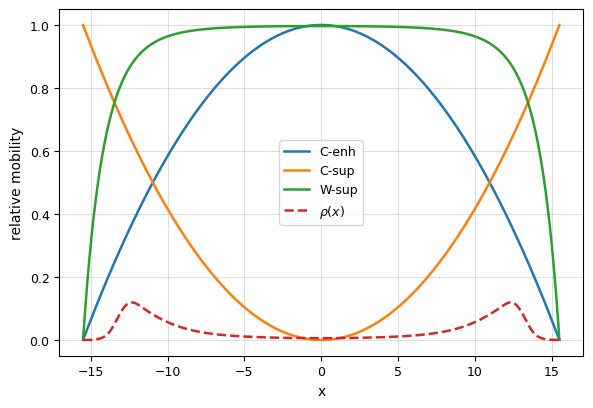

In [ ]:
def b_func1(x, alpha=1.0, beta=1.0, L=15.5):
  return alpha * (1 - beta * (x/L)**2)

def b_func2(x, alpha=1.0, L=15.5):
  return alpha * ((x/L)**2)

def b_func3(x, alpha=1.0, beta=1.0, delta=6.5, xw=15.5):
  return alpha * (1 - beta * np.exp((x**2-xw**2)/delta**2))

x = tables_spline[(3, 0.1)]["x"]
dens = tables_spline[(3, 0.1)]["density"]

plt.figure(figsize=(6.76, 4.5))
plt.plot(x, b_func1(x), label="C-enh", lw=1.8)
plt.plot(x, b_func2(x), label="C-sup", lw=1.8)
plt.plot(x, b_func3(x), label="W-sup", lw=1.8)
plt.plot(x, dens, ls="--", label=r"$\rho(x)$", lw=1.8)
plt.xlabel("x")
plt.ylabel("relative mobility")
plt.legend()
plt.grid(alpha=0.4)
fig_name="mobility_function_examples"
#plt.savefig(fig_dir + "/" + fig_name + ".pdf", bbox_inches="tight")
plt.show()

In [ ]:
X_plus = launch_EMOL_solver_general(tables_spline,
                                    (6, 0.8),
                                    b_func = lambda x: 1,
                                    N=250_000, M=1024,
                                    dt=2.67e-4,
                                    eps=None,
                                    ic="pdf",
                                    rngseed=host_seed)

ACFs = acovs_WK_unbiased(X_plus)

ACFs = ACFs / ACFs[:, [0]]

ACF_mu_plus = ACFs.mean(axis=0)
ACF_sd_plus = ACFs.std(axis=0)

In [ ]:
X_minus = launch_EMOL_solver_general(tables_spline,
                                    (6, 0.8),
                                    b_func = lambda x: 1,
                                    N=500_000, M=1024,
                                    dt=2.67e-4,
                                    eps=None,
                                    ic="pdf",
                                    rngseed=host_seed)

ACFs = acovs_WK_unbiased(X_minus)

ACFs = ACFs / ACFs[:, [0]]

ACF_mu_minus = ACFs.mean(axis=0)
ACF_sd_minus = ACFs.std(axis=0)

In [ ]:
X_three = launch_EMOL_solver_general(tables_spline,
                                    (3, 0.1),
                                    b_func = b_func1,
                                    N=750_000, M=512,
                                    dt=2.67e-4,
                                    eps=None,
                                    ic="pdf",
                                    rngseed=host_seed)

ACFs = acovs_WK_unbiased(X_three)

ACFs = ACFs / ACFs[:, [0]]

ACF_mu_three = ACFs.mean(axis=0)
ACF_sd_three = ACFs.std(axis=0)

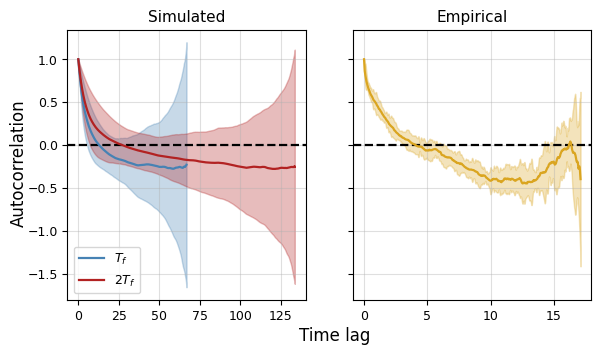

In [ ]:
lags_plus = np.arange(len(ACF_mu_plus)) * 2.67e-4
lags_minus = np.arange(len(ACF_mu_minus)) * 2.67e-4
#lags_three = np.arange(len(ACF_mu_three)) * 2.67e-4

step=100

fig, axes = plt.subplots(1, 2, figsize=(6.76, 3.5), sharex=False, sharey=True)

axes[0].axhline(0, c="k", ls="--", alpha=1)
axes[0].plot(lags_plus[::step], ACF_mu_plus[::step], label=r"$T_f$", c="steelblue")
axes[0].fill_between(lags_plus[::step],
                     ACF_mu_plus[::step] - ACF_sd_plus[::step],
                     ACF_mu_plus[::step] + ACF_sd_plus[::step],
                     alpha=0.3,
                     color="steelblue")

axes[0].plot(lags_minus[::step], ACF_mu_minus[::step], label=r"$2T_f$", c="firebrick")
axes[0].fill_between(lags_minus[::step],
                     ACF_mu_minus[::step] - ACF_sd_minus[::step],
                     ACF_mu_minus[::step] + ACF_sd_minus[::step],
                     alpha=0.3,
                     color="firebrick")

axes[0].set_title("Simulated")
axes[0].grid(alpha=0.4)
axes[0].legend()

lags_emp = np.arange(len(ACF_mu_emp)) * 2.67e-4

axes[1].axhline(0, c="k", ls="--")
axes[1].plot(lags_emp[::step], ACF_mu_emp[::step], c="goldenrod")
axes[1].fill_between(lags_emp[::step],
                     ACF_mu_emp[::step] - ACF_sd_emp[::step],
                     ACF_mu_emp[::step] + ACF_sd_emp[::step],
                     alpha=0.3,
                     color="goldenrod")
axes[1].set_title("Empirical")
axes[1].grid(alpha=0.4)

fig.supxlabel("Time lag", y=-0.02, x=1.04/2)
fig.supylabel("Autocorrelation", x=0.04, y=1.0/2)
fig_name="sim_vs_emp_ACF"
#plt.savefig(fig_dir + "/" + fig_name + ".pdf", bbox_inches="tight")
plt.show()

In [ ]:
emp_ACF_data = {}

c = 0
for w in widths:
  for Ca in CaArr:
    read_path = emp_ACF_dir + f"/ACF_w{w}_Ca{Ca}.npz"
    subset = np.load(read_path, allow_pickle=True)

    if c <= 0:
      print(subset.files)
      c += 1

    acf_mu = subset["acf"]
    acf_sd = subset["acf_sd"]

    emp_ACF_data[(w, Ca)] = {
        "acf_mu": acf_mu,
        "acf_sd": acf_sd    }

['acf', 'acf_sd']


In [ ]:
ACF_mu_emp = emp_ACF_data[(6, 0.8)]["acf_mu"]
ACF_sd_emp = emp_ACF_data[(6, 0.8)]["acf_sd"]

In [ ]:
X = launch_EMOL_solver_general(tables_spline,
                               (3, 0.1),
                               b_func = b_func2,
                               N=250_000, M=1024,
                               dt=1e-4,
                               eps=None,
                               ic="pdf",
                               rngseed=host_seed)

ACFs = acovs_WK_unbiased(X)

ACFs = ACFs / ACFs[:, [0]]

ACF_mu = ACFs.mean(axis=0)
ACF_sd = ACFs.std(axis=0)

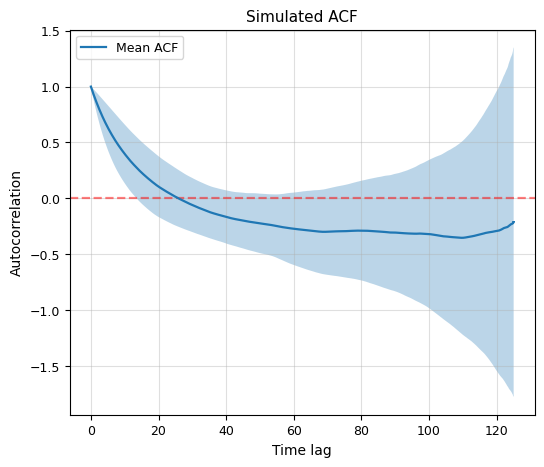

In [ ]:
lags = np.arange(len(ACF_mu)) * 1e-4

plt.figure(figsize=(6,5))
plt.axhline(0, c="r", ls="--", alpha=0.5)
plt.plot(lags, ACF_mu, label="Mean ACF")
plt.fill_between(lags,
                 ACF_mu - ACF_sd,
                 ACF_mu + ACF_sd,
                 alpha=0.3)
plt.xlabel("Time lag")
plt.ylabel("Autocorrelation")
plt.title("Simulated ACF")
plt.grid(alpha=0.4)

#plt.xlim(0, 64001)

plt.legend()
plt.show()

In [ ]:
hit_steps, xhit = launch_hits_for_MFPT_LtoR(tables_spline, (3, 0.1), b_func3,
                                            tol_dic[(3, 0.1)]["tol_Lr"],
                                            Nmax=5e8, M=1024,
                                            dt=2.67e-4, eps=None, ic="wL",
                                            rngseed=host_seed)

In [ ]:
hit_times = 2.67e-4 * hit_steps

tau_hits = hit_times[hit_times >= 0]
tau_cens = hit_times[hit_times < 0]

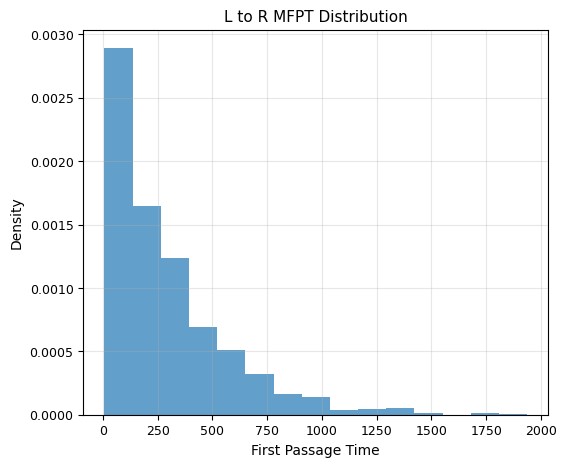

1024 0


In [ ]:
plt.figure(figsize=(6,5))

plt.hist(
    tau_hits,
    bins=15,
    density=True,
    alpha=0.7
)

plt.xlabel("First Passage Time")
plt.ylabel("Density")
plt.title("L to R MFPT Distribution")
plt.grid(alpha=0.3)

plt.show()

print(len(tau_hits), len(tau_cens))

In [ ]:
lam = 1.0 / np.mean(tau_hits)
mfpt = np.mean(tau_hits)

tau_sorted = np.sort(tau_hits)
N = len(tau_sorted)
S = 1.0 - np.arange(1, N+1) / N

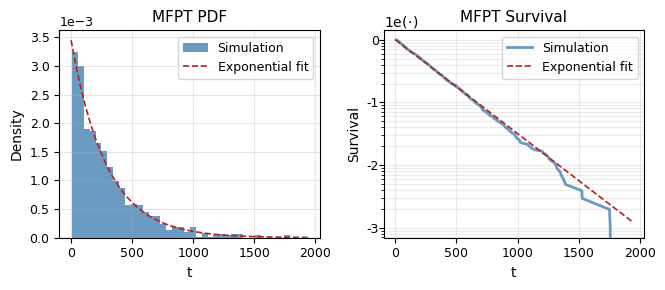

0.003449272168967962 289.9162347919922


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(6.76, 3.0))

# -----------------------
# LEFT: PDF
# -----------------------
axes[0].hist(tau_hits, bins=40, density=True, alpha=0.8, label="Simulation", color="steelblue")

t_plot = np.linspace(0, tau_sorted[-1], 400)
axes[0].plot(t_plot, lam*np.exp(-lam*t_plot),
             c="firebrick", ls="--", lw=1.2,
             alpha=1.0, label="Exponential fit")

axes[0].set_xlabel("t")
axes[0].set_ylabel("Density")
axes[0].set_title("MFPT PDF")
axes[0].ticklabel_format(style="sci", axis="y", scilimits=(0,0))
axes[0].grid(alpha=0.3)
axes[0].legend()

# -----------------------
# RIGHT: Survival
# -----------------------
axes[1].plot(tau_sorted, S, lw=2, label="Simulation", c="steelblue", alpha=0.8)
axes[1].plot(t_plot, np.exp(-lam*t_plot),
             c="firebrick", ls="--", lw=1.2,
             alpha=1.0, label="Exponential fit")

axes[1].set_yscale("log")
axes[1].set_xlabel("t")
axes[1].set_ylabel("Survival")
axes[1].set_title("MFPT Survival")
axes[1].yaxis.set_major_locator(LogLocator(base=10))
axes[1].yaxis.set_major_formatter(FuncFormatter(log_exponent_formatter))
axes[1].text(0.00, 1.00, r"1e$(\!\cdot\!)$", transform=axes[1].transAxes, ha="left", va="bottom")
axes[1].tick_params(axis="y", rotation=0, pad=0)
axes[1].legend()
axes[1].grid(which="both", alpha=0.25)

plt.tight_layout(rect=[0, 0, 1, 1])
#fig_name="b_func3_MFPT_example_FAST"
plt.savefig(fig_dir + "/" + fig_name + ".pdf", bbox_inches="tight")
plt.show()
print(lam, mfpt)

In [ ]:
hit_steps_plus, xhit_plus = launch_hits_for_MFPT_LtoR(
    tables_spline, (3, 0.1),
    b_func3,
    tol_dic[(3, 0.1)]["tol_Lr"],
    Nmax=5e8, M=1024,
    dt=2.67e-4, eps=None, ic="wL",
    rngseed=host_seed)

In [ ]:
hit_steps_minus, xhit_minus = launch_hits_for_MFPT_LtoR(
    tables_spline, (3, 0.1),
    b_func3,
    tol_dic[(3, 0.1)]["tol_Lr"],
    Nmax=5e8, M=1024,
    dt=2.67e-4, eps=None, ic="wL",
    rngseed=host_seed)

In [ ]:
hit_times_plus = 2.67e-4 * hit_steps_plus
tau_hits_plus = hit_times_plus[hit_times_plus >= 0]
tau_cens_plus = hit_times_plus[hit_times_plus < 0]

hit_times_minus = 2.67e-4 * hit_steps_minus
tau_hits_minus = hit_times_minus[hit_times_minus >= 0]
tau_cens_minus = hit_times_minus[hit_times_minus < 0]

In [ ]:
lam_plus = 1.0 / np.mean(tau_hits_plus)
mfpt_plus = np.mean(tau_hits_plus)
tau_sorted_plus = np.sort(tau_hits_plus)

lam_minus = 1.0 / np.mean(tau_hits_minus)
mfpt_minus = np.mean(tau_hits_minus)
tau_sorted_minus = np.sort(tau_hits_minus)

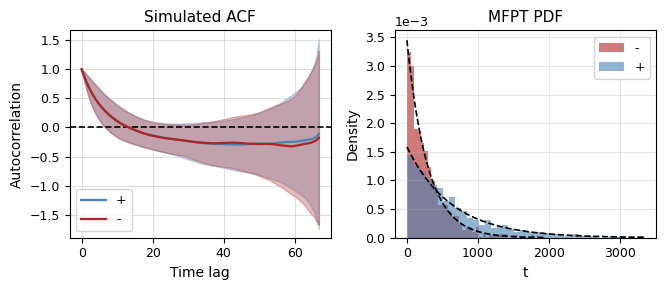

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(6.76, 3.0))

# -----------------------
# LEFT: ACF
# -----------------------
axes[0].axhline(0, c="k", ls="--", alpha=1, lw=1.2)
axes[0].plot(lags, ACF_mu_plus, c="steelblue", label="+")
axes[0].fill_between(lags,
                 ACF_mu_plus - ACF_sd_plus,
                 ACF_mu_plus + ACF_sd_plus,
                 alpha=0.3,
                 color="steelblue")

axes[0].plot(lags, ACF_mu_minus, c="firebrick", label="-")
axes[0].fill_between(lags,
                 ACF_mu_minus - ACF_sd_minus,
                 ACF_mu_minus + ACF_sd_minus,
                 alpha=0.3,
                 color="firebrick")
axes[0].set_xlabel("Time lag")
axes[0].set_ylabel("Autocorrelation")
axes[0].set_title("Simulated ACF")
axes[0].legend()
axes[0].grid(alpha=0.4)

# -----------------------
# RIGHT: PDF
# -----------------------
axes[1].hist(tau_hits_minus, bins=40, density=True, alpha=0.6, label="-", color="firebrick")
t_plot = np.linspace(0, tau_sorted_minus[-1], 400)
axes[1].plot(t_plot, lam_minus*np.exp(-lam_minus * t_plot),
             c="k", ls="--", lw=1.2,
             alpha=1.0)

axes[1].hist(tau_hits_plus, bins=40, density=True, alpha=0.6, label="+", color="steelblue")
t_plot = np.linspace(0, tau_sorted_plus[-1], 400)
axes[1].plot(t_plot, lam_plus*np.exp(-lam_plus * t_plot),
             c="k", ls="--", lw=1.2,
             alpha=1.0)

axes[1].set_xlabel("t")
axes[1].set_ylabel("Density")
axes[1].set_title("MFPT PDF")
axes[1].ticklabel_format(style="sci", axis="y", scilimits=(0,0))
axes[1].legend()
axes[1].grid(alpha=0.3)

#fig.legend(loc="lower right", bbox_to_anchor=None, ncol=2, frameon=True)
plt.tight_layout(rect=[0, 0, 1, 1])

fig_name="time_scale_seperation"
#plt.savefig(fig_dir + "/" + fig_name + ".pdf", bbox_inches="tight")
plt.show()

In [ ]:
#MFPTs = []
MFPTs.append(mfpt)

In [ ]:
MFPTs

[np.float64(630.8683569345703), np.float64(289.9162347919922)]

In [ ]:
clean_dir = "/content/drive/My Drive/MSci Maths/Cleaned Data"
relstat_dir = clean_dir + "/Relevant Statistics"
emp_ACF_dir = relstat_dir + "/Empirical/ACFs (full tail)"

# MFPT kappa
tau_emp = 1.475408625             # dt = 2.67e-6 (LBM)
tau_sim_old = 805.694             # dt = 2.67e-4
tau_sim_1e5 = 1497.705            # dt = 1e-5
tau_sim_test =                    # dt = 2.67e-4
kappa_test =                      #

emp_ACF_data = {}

c = 0
for w in [3]:
  for Ca in [0.1]:
    read_path = emp_ACF_dir + f"/ACF_w{w}_Ca{Ca}.npz"
    subset = np.load(read_path, allow_pickle=True)

    if c <= 0:
      print(subset.files)
      c += 1

    acf_mu = subset["acf"]
    acf_sd = subset["acf_sd"]

    emp_ACF_data[(w, Ca)] = {
        "acf_mu": acf_mu,
        "acf_sd": acf_sd    }

['acf', 'acf_sd']


In [ ]:
ACF_emp_mu, ACF_emp_sd = emp_ACF_data[(3, 0.1)]["acf_mu"], emp_ACF_data[(3, 0.1)]["acf_sd"]

In [ ]:
X = launch_EMOL_solver_general(tables_spline,
                               (3, 0.1),
                               b_func = b_func3,
                               N=2_500_000, M=1024,
                               dt=2.67e-4,
                               eps=None,
                               ic="pdf",
                               rngseed=host_seed)

ACFs = acovs_WK_unbiased(X)

ACFs = ACFs / ACFs[:, [0]]

ACF_mu = ACFs.mean(axis=0)
ACF_sd = ACFs.std(axis=0)

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


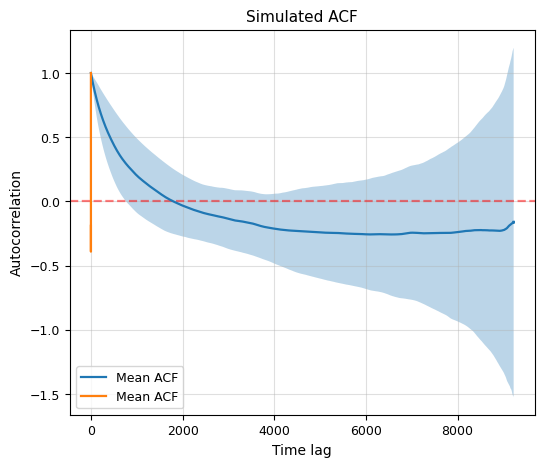

In [ ]:
lags_sim = np.arange(len(ACF_mu)) * 2.67e-4 * kappa_test
lags_emp = np.arange(len(ACF_emp_mu)) * 2.67e-6

plt.figure(figsize=(6,5))
plt.axhline(0, c="r", ls="--", alpha=0.5)
plt.plot(lags_sim, ACF_mu, label="Mean ACF")
plt.fill_between(lags_sim,
                 ACF_mu - ACF_sd,
                 ACF_mu + ACF_sd,
                 alpha=0.3)

plt.plot(lags_emp, ACF_emp_mu, label="Mean ACF")
plt.fill_between(lags_emp,
                 ACF_emp_mu - ACF_emp_sd,
                 ACF_emp_mu + ACF_emp_sd,
                 alpha=0.3)

plt.xlabel("Time lag")
plt.ylabel("Autocorrelation")
plt.title("Simulated ACF")
plt.grid(alpha=0.4)

#plt.xlim(0, 64001)

plt.legend()
plt.show()

In [ ]:
def fit_acf_exponential(t, acf, frac=0.2):
  """
  Fit early-time exponential decay:
  C(t) ~ exp(-lambda t)

  frac = fraction of usable positive segment used for fitting
  """

  # Keep only positive values
  mask_pos = acf > 0
  t_pos = t[mask_pos]
  acf_pos = acf[mask_pos]

  if len(acf_pos) < 500:
    print("Short ACF.")
    return np.nan

  # Find first zero crossing
  zero_idx = np.argmax(~mask_pos)
  if zero_idx == 0:
    zero_idx = len(acf_pos)

  usable_len = int(frac * zero_idx)

  if usable_len < 500:
    usable_len = min(250, len(acf_pos))

  t_fit = t_pos[:usable_len]
  y_fit = np.log(acf_pos[:usable_len])

  # Linear fit
  slope, intercept = np.polyfit(t_fit, y_fit, 1)

  lambda_hat = -slope
  tau_hat = 1.0 / lambda_hat

  return lambda_hat, tau_hat

In [ ]:
t_emp = np.arange(len(ACF_emp_mu)) * 2.67e-6
t_sim = np.arange(len(ACF_mu)) * 2.67e-4

lam_emp, tau_emp = fit_acf_exponential(t_emp, ACF_emp_mu)
lam_sim, tau_sim = fit_acf_exponential(t_sim, ACF_mu)

kappa_test2 = tau_emp/tau_sim
print(kappa_test2)

0.0005742632303429955


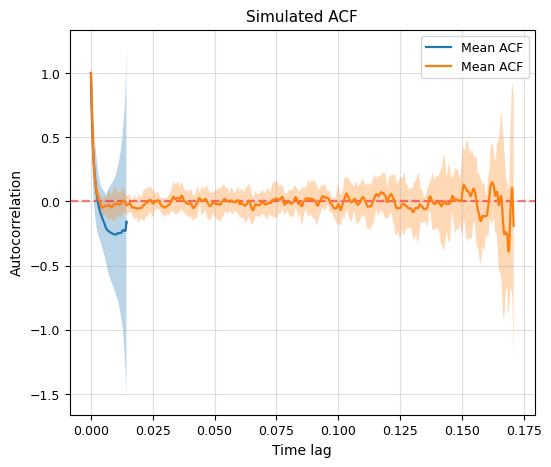

In [ ]:
lags_sim = np.arange(len(ACF_mu)) * 2.67e-4 * kappa_test2
lags_emp = np.arange(len(ACF_emp_mu)) * 2.67e-6

plt.figure(figsize=(6,5))
plt.axhline(0, c="r", ls="--", alpha=0.5)
plt.plot(lags_sim, ACF_mu, label="Mean ACF")
plt.fill_between(lags_sim,
                 ACF_mu - ACF_sd,
                 ACF_mu + ACF_sd,
                 alpha=0.3)

plt.plot(lags_emp, ACF_emp_mu, label="Mean ACF")
plt.fill_between(lags_emp,
                 ACF_emp_mu - ACF_emp_sd,
                 ACF_emp_mu + ACF_emp_sd,
                 alpha=0.3)

plt.xlabel("Time lag")
plt.ylabel("Autocorrelation")
plt.title("Simulated ACF")
plt.grid(alpha=0.4)

#plt.xlim(0, 64001)

plt.legend()
plt.show()

# Kramers

In [ ]:
def get_well_and_saddle(x, V):
  dV = np.gradient(V, x)
  sign_change = np.diff(np.sign(dV))

  # minima: derivative changes - → +
  minima_idx = np.where(sign_change > 0)[0] + 1

  # maxima: derivative changes + → -
  maxima_idx = np.where(sign_change < 0)[0] + 1

  if len(minima_idx) < 2 or len(maxima_idx) < 1:
    raise RuntimeError("Potential not clearly double-well.")

  # assume symmetric: take left minimum
  left_min_idx = minima_idx[np.argmin(x[minima_idx])]
  saddle_idx = maxima_idx[0]  # central barrier

  return left_min_idx, saddle_idx

def kramers_time_from_subset(subset):
  x = subset["x"]
  V = subset["V"]
  eps = subset["eps"]

  # find well and saddle
  i_min, i_sad = get_well_and_saddle(x, V)

  x_min = x[i_min]
  x_sad = x[i_sad]

  V_min = V[i_min]
  V_sad = V[i_sad]

  deltaV = V_sad - V_min

  # second derivatives
  Vpp = np.gradient(np.gradient(V, x), x)

  curv_min = Vpp[i_min]
  curv_sad = Vpp[i_sad]

  tau_K = (
      2 * np.pi
      / np.sqrt(abs(curv_sad) * curv_min)
      * np.exp(deltaV / eps)
  )

  return {
      "tau_K": tau_K,
      "deltaV": deltaV,
      "curv_min": curv_min,
      "curv_sad": curv_sad
  }

In [ ]:
kramers = {}

for key, subset in tables_spline.items():
  kramers[key] = kramers_time_from_subset(subset)